 # IHDP Benchmark



 Before I trust any causal ML method on real data, I want to check it

 actually works when I know the right answer. That's what this notebook

 does — IHDP is a semi-synthetic dataset (real covariates, but simulated

 outcomes with a known true treatment effect for every unit), so I can

 score each estimator against ground truth instead of just eyeballing it.



 It's the standard benchmark for this in the causal ML literature (Hill

 2011, Wager & Athey 2018, etc.), which is also why I picked it — I wanted

 something I could sanity-check my implementation against.

In [1]:
import numpy as np
import pandas as pd
from econml.data.dgps import ihdp_surface_B
from econml.metalearners import TLearner, XLearner
from econml.grf import CausalForest
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
%matplotlib inline
RNG = 42
np.random.seed(RNG)


 ### Metric: PEHE



 Regular prediction accuracy (how well you predict Y) isn't the same

 thing as treatment effect accuracy — a model can nail the outcome and

 still get the effect wrong. PEHE is RMSE computed against the true

 treatment effect specifically, which is why it's the metric everyone

 uses for this.

In [2]:
def pehe(tau_true, tau_hat):
    return np.sqrt(np.mean((tau_true - tau_hat) ** 2))


def ate_error(tau_true, tau_hat):
    return abs(tau_true.mean() - tau_hat.mean())


 ### Three estimators



 T-learner fits one model per treatment arm and subtracts. X-learner adds

 a propensity-weighting correction on top, which should help when the

 treatment groups are imbalanced (only ~19% treated here). Causal Forest

 uses honest splitting so it can give valid confidence intervals, not

 just point estimates.



 Running this 10 times with different splits since one split could just

 get lucky.

In [3]:
def run_benchmark(n_repeats=10):
    results = []

    for rep in range(n_repeats):
        Y, T, X, tau_true = ihdp_surface_B()
        X_tr, X_te, T_tr, T_te, Y_tr, Y_te, tau_tr, tau_te = train_test_split(
            X, T, Y, tau_true, test_size=0.3, random_state=RNG + rep
        )

        t_learner = TLearner(models=GradientBoostingRegressor(random_state=RNG))
        t_learner.fit(Y_tr, T_tr, X=X_tr)
        tau_hat_t = t_learner.effect(X_te)

        x_learner = XLearner(models=GradientBoostingRegressor(random_state=RNG))
        x_learner.fit(Y_tr, T_tr, X=X_tr)
        tau_hat_x = x_learner.effect(X_te)

        cf = CausalForest(n_estimators=500, random_state=RNG, honest=True)
        cf.fit(X_tr, T_tr, Y_tr)
        tau_hat_cf = cf.predict(X_te).flatten()

        for name, tau_hat in [
            ("T-learner", tau_hat_t),
            ("X-learner", tau_hat_x),
            ("Causal Forest", tau_hat_cf),
        ]:
            results.append({
                "repeat": rep,
                "method": name,
                "PEHE": pehe(tau_te, tau_hat),
                "ATE_error": ate_error(tau_te, tau_hat),
            })

    return pd.DataFrame(results)


In [4]:
df = run_benchmark(n_repeats=10)
summary = df.groupby("method")[["PEHE", "ATE_error"]].agg(["mean", "std"])
print(summary)


                   PEHE           ATE_error          
                   mean       std      mean       std
method                                               
Causal Forest  3.557055  3.133458  0.500973  0.688531
T-learner      2.175726  1.828634  0.260967  0.444654
X-learner      2.977566  2.487064  0.383228  0.612532


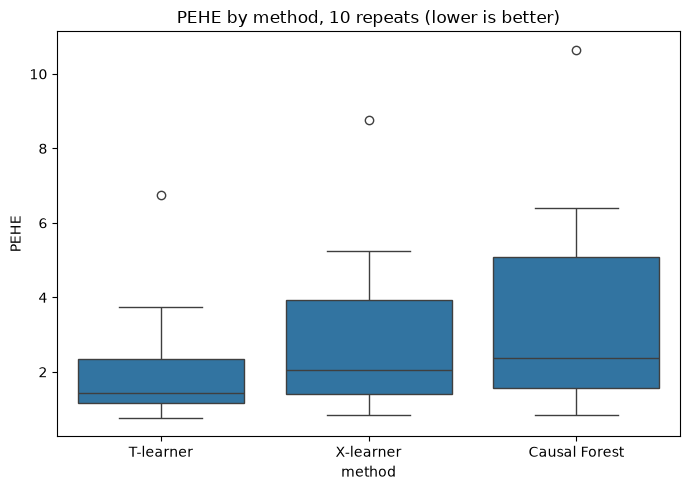

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x="method", y="PEHE", ax=ax)
ax.set_title("PEHE by method, 10 repeats (lower is better)")
ax.set_ylabel("PEHE")
plt.tight_layout()
plt.show()


In [6]:
summary.to_csv("results_ihdp_benchmark.csv")
df.to_csv("results_ihdp_benchmark_raw.csv", index=False)


 T-learner actually did best here, which wasn't what I expected going in

 — I assumed X-learner and Causal Forest, being more sophisticated, would

 win. My guess is IHDP is just small (~750 units), so the extra machinery

 in the other two doesn't have enough data to earn its keep. Worth

 flagging as a real finding rather than glossing over it.